In [48]:
# Standard library imports
import os
import sys
import random
import warnings
import math

# Third-party numerical and data handling
import numpy as np
import pandas as pd
import h5py
import cv2
from PIL import Image

# Visualization
import matplotlib.pyplot as plt
from tqdm import tqdm

# Machine learning utilities
from sklearn.metrics import (
    average_precision_score,
    label_ranking_average_precision_score,
    roc_auc_score,
    brier_score_loss,
    f1_score
)

# PyTorch core
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torch.amp import autocast, GradScaler

# PyTorch vision
from torchvision import models

# Albumentations
import albumentations as A
from albumentations.core.transforms_interface import ImageOnlyTransform
from albumentations.pytorch import ToTensorV2

# Custom modules (Kaggle inputs)
# sys.path.append("/kaggle/input/asymmetric-loss-dataset")
# sys.path.append("/kaggle/input/data-preprocessing")
# sys.path.append("/kaggle/input/data-transformations")

from losses import AsymmetricLossOptimized
from preprocess import ecg_processing_pipeline, smart_pad_and_resize_ecg, ecg_processing_pipeline_no_perspective_distortion
from transformations import CornerCutout, GradientShadow, PaperFoldEffect, BottomBlur

In [49]:
def check_device():
    """
    Check available compute devices and return the best one.
    Priority: CUDA > MPS > CPU
    """
    if torch.cuda.is_available():
        device = torch.device("cuda")
        print("✓ CUDA available")
        print(f"  GPU: {torch.cuda.get_device_name(0)}")
        print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
        print("✓ MPS (Apple Silicon GPU) available")
    else:
        device = torch.device("cpu")
        print("✗ Using CPU (no GPU acceleration available)")
    
    print(f"\nSelected device: {device}")
    return device

# Check and get device
device = check_device()

✓ MPS (Apple Silicon GPU) available

Selected device: mps


In [50]:
model = "ConvNext"

In [51]:
class Head(nn.Module):
    def __init__(self, in_features, hidden_layer, dropout_rate=0.3):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(in_features, hidden_layer),
            nn.BatchNorm1d(hidden_layer),  
            nn.GELU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(hidden_layer, hidden_layer // 2), 
            nn.BatchNorm1d(hidden_layer // 2),
            nn.GELU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(hidden_layer // 2, 1)
        )
    
    def forward(self, x):
        return self.layers(x)

if model == "EfficientNet":
    class MultiHeadEfficientNet(nn.Module):
        def __init__(self, num_conditions=5, hidden_dim=512, dropout_rate=0.3):
            super().__init__()
            
            backbone = models.efficientnet_v2_s(weights="DEFAULT")
            in_features = backbone.classifier[1].in_features
            backbone.classifier = nn.Identity()
            
            self.backbone = backbone
            
            self.shared_feature_processor = nn.Sequential(
                nn.Linear(in_features, in_features), 
                nn.BatchNorm1d(in_features),
                nn.GELU(), 
                nn.Dropout(p=dropout_rate),
                nn.Linear(in_features, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.GELU(),
                nn.Dropout(p=dropout_rate)
            )
            
            self.heads = nn.ModuleList([
                Head(hidden_dim, hidden_dim // 2, dropout_rate) 
                for _ in range(num_conditions)
            ])
            
        def forward(self, x):
            backbone_feats = self.backbone(x)
            processed_feats = self.shared_feature_processor(backbone_feats)
            outputs = [head(processed_feats) for head in self.heads]
            return torch.cat(outputs, dim=1)  # [batch, num_conditions]
elif model == "ConvNext": 

    class MultiHeadEfficientNet(nn.Module):
        def __init__(self, num_conditions=5, hidden_dim=512, dropout_rate=0.3):
            super().__init__()
            
            backbone = models.convnext_base(weights="IMAGENET1K_V1", progress=True)
            in_features = backbone.classifier[2].in_features
            assert isinstance(in_features, int), f"in_features should be int, got {type(in_features)}"
            
            backbone.classifier = nn.Identity()
            self.backbone = backbone
            
            self.shared_feature_processor = nn.Sequential(
                nn.Linear(in_features, in_features), 
                nn.BatchNorm1d(in_features),
                nn.GELU(), 
                nn.Dropout(p=dropout_rate),
                nn.Linear(in_features, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.GELU(),
                nn.Dropout(p=dropout_rate)
            )
            
            self.heads = nn.ModuleList([
                Head(hidden_dim, hidden_dim // 2, dropout_rate) 
                for _ in range(num_conditions)
            ])
            
        def forward(self, x):
            backbone_feats = self.backbone(x).flatten(1) # squeeze non-batch dimension
            processed_feats = self.shared_feature_processor(backbone_feats)
            outputs = [head(processed_feats) for head in self.heads]
            return torch.cat(outputs, dim=1)  # [batch, num_conditions]
        
else: 
    
    raise Exception("Model not recognised")

In [52]:
def load_contours_from_hdf5(filepath='/kaggle/input/ecg-image-contours/contours.h5'):
    """
    Load all contours from HDF5 file back into dictionary format
    """
    contour_dict = {}
    
    with h5py.File(filepath, 'r') as f:
        for img_id in f.keys():
            grp = f[img_id]
            
            contour_dict[img_id] = {
                'contour': grp['contour'][:],  # Load the contour array
                'scale_x': grp.attrs['scale_x'],
                'scale_y': grp.attrs['scale_y'], 
                'half': grp.attrs['half']
            }
    
    return contour_dict

# Usage
try: 
    print(contours["train_000000"])
except Exception as e: 
    contours = load_contours_from_hdf5(filepath=os.path.join(os.path.abspath("../"), "data", "contours.h5"))

{'contour': array([[[464, 236]],

       [[463, 237]],

       [[462, 237]],

       ...,

       [[467, 236]],

       [[466, 236]],

       [[465, 236]]], shape=(1109, 1, 2), dtype=int16), 'scale_x': np.float64(9.010416666666666), 'scale_y': np.float64(4.947916666666667), 'half': np.int64(192)}


In [54]:
def process_single_img(
                img,
                img_id,
                desired_aspect=0.5,
                target_width=512
                ):
    value = f"train_{str(img_id).zfill(6)}.png"
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    
    # output = ecg_processing_pipeline(input_image = img, 
    #                             contour_data = contours[value.split(".")[0]])
    
    output = ecg_processing_pipeline_no_perspective_distortion(input_image = img, 
                                contour_data = contours[value.split(".")[0]])
    
    resize_output = smart_pad_and_resize_ecg(output, target_size=(int(target_width*desired_aspect), 512), resize_strategy=cv2.INTER_AREA)
    return resize_output

def imread_clean(path):
    img = Image.open(path)
    img = img.convert('RGB')  # Strips metadata
    return np.array(img)

class ECGDataset(Dataset): 
    def __init__(self,
                image_paths, 
                labels_df, 
                transforms=None):
        
        self.image_paths = image_paths
        self.labels_dict = {idx: torch.tensor(row.values, dtype=torch.float32) 
                            for idx, row in labels_df.iterrows()}
        
        self.idx_to_image_id = {}
        for idx, path in enumerate(self.image_paths):
            filename = os.path.basename(path)
            image_id = int(filename.rsplit('_', 1)[-1].split('.')[0])
            self.idx_to_image_id[idx] = image_id
        
        self.transforms = transforms
        
    def __len__(self): 
        return len(self.image_paths)
        
    def __getitem__(self, idx): 
        image_path = self.image_paths[idx]
        index = self.idx_to_image_id[idx]
        label = self.labels_dict[index]
        image = imread_clean(image_path)
        if image is None:
            raise ValueError(f"Failed to load image: {image_path}")
        # convert image using our segmentation pipeline 
        image_conv = process_single_img(
            img=image, 
            img_id=index,
            desired_aspect=0.5, 
            target_width=512
        )
        image_conv = np.stack([image_conv, image_conv, image_conv], axis=-1)
        if self.transforms is not None: 
            image_tens = self.transforms(image=image_conv)["image"]
        else: 
            image_tens = image_conv
        return image_tens, label

In [55]:
val_transforms = A.Compose([
    A.CLAHE(
        clip_limit=4,
        tile_grid_size=(8, 8),
        p=1.0
    ),
    # Normalization (ImageNet)
    A.Normalize(mean=[0.485, 0.456, 0.406], 
                std=[0.229, 0.224, 0.225]),
    # Convert to tensor
    ToTensorV2()
])

In [56]:
from sklearn.model_selection import train_test_split

root_path = os.path.abspath("../")
data_path = os.path.join(root_path, "data")
imagefile_path = os.path.join(root_path, "broken_images")

labels_df = pd.read_csv(os.path.join(data_path, "train_final.csv"), index_col=0, dtype=int)

with open(os.path.join(imagefile_path, "broken_images_list.txt"), "r") as file:
    broken_train_images = [line.strip() for line in file]
with open(os.path.join(imagefile_path, "broken_test_images_list.txt"), "r") as file:
    broken_test_images = [line.strip() for line in file]
with open(os.path.join(imagefile_path, "valid_images_list.txt"), "r") as file:
    valid_train_images = [line.strip() for line in file]
with open(os.path.join(imagefile_path, "valid_test_images_list.txt"), "r") as file:
    valid_test_images = [line.strip() for line in file]

all_ids = set([int(obj.split(".")[-2][-6:]) for obj in valid_train_images])

labels_df = labels_df.loc[labels_df.index.isin(all_ids)]

# split train set, using stratification 
X_train, X_test, y_train, y_test = train_test_split(valid_train_images, 
                                                    labels_df, 
                                                    test_size = 0.2,
                                                    random_state = 42, 
                                                    shuffle = True, 
                                                    stratify = labels_df[["CD", "MI", "AF", "STTC", "HYP"]])

In [57]:
# identify which of these images we actually have locally
import glob 
local_files = glob.glob(os.path.abspath(os.path.join(data_path, "train", "train_*")))
indices = set([int(item.split(".")[0][-6:]) for item in local_files])

# usable local ids 
local_ids = indices.intersection(all_ids)

# downsample ids to be more tractable numbers
#local_ids = [id_val for ind, id_val in enumerate(local_ids) if ind%10 == 0]

# filter X_train and X_test to only contain the correct ids
X_train_usable = [elem for elem in X_train if int(elem.split(".")[0][-6:]) in local_ids]
X_test_usable = [elem for elem in X_test if int(elem.split(".")[0][-6:]) in local_ids]

# rewrite paths to actually be the local ones
X_train = [os.path.abspath(os.path.join("../", "data", "train", path.split("/")[-1])) for path in X_train_usable]
X_test = [os.path.abspath(os.path.join("../", "data", "train", path.split("/")[-1])) for path in X_test_usable]

In [58]:
from torch.utils.data import random_split

val_dataset = ECGDataset(
                    image_paths=X_test, 
                    labels_df=labels_df, 
                    transforms=val_transforms, 
                    ) 
val_size = len(val_dataset)
calib_size = int(0.5 * val_size)
eval_size = val_size - calib_size

val_calib_ds, val_eval_ds = random_split(val_dataset, lengths=[calib_size, eval_size])

In [59]:
num_workers = 0 if sys.platform == 'darwin' else 4 
print(f"Using num_workers = {num_workers}")

val_dataloader = DataLoader( 
                        val_dataset,
                        batch_size=8, 
                        shuffle=False, 
                        num_workers=num_workers, 
                        pin_memory=True if device.type == "cuda" else False)

val_calib_dl = DataLoader(
                val_calib_ds, 
                batch_size=32, 
                shuffle=False, 
                num_workers=num_workers, 
                    )

val_eval_dl = DataLoader(
                val_eval_ds, 
                batch_size=32, 
                shuffle=False, 
                num_workers=num_workers, 
                    )

Using num_workers = 0


In [61]:
def compute_ece(y_true, y_pred, n_bins=15):
    """
    Expected Calibration Error for binary predictions.
    y_true, y_pred are 1D arrays for one label.
    """
    if len(np.unique(y_true)) < 2:
        return float('nan')  # no ECE if only one class
    
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    N = len(y_true)

    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        mask = (y_pred >= lo) & (y_pred < hi)
        if np.sum(mask) == 0:
            continue
        
        bin_accuracy = np.mean(y_true[mask])
        bin_confidence = np.mean(y_pred[mask])
        ece += (np.sum(mask) / N) * abs(bin_accuracy - bin_confidence)
    
    return float(ece)

def compute_ranking_metrics(all_y_true, all_y_pred):
    """
    Compute AP/AUROC/LRAP ranking metrics and calibration metrics.
    Inputs are numpy arrays.
    """
    L = all_y_true.shape[1]

    per_label_ap = []
    per_label_auroc = []
    per_label_brier = []
    per_label_brier_baseline = []
    thresholds = []
    per_label_f1s = []
    per_label_ece = []
    
    for j in range(L):
        
        y_true = all_y_true[:, j]
        y_pred = all_y_pred[:, j]

        unique_classes = np.unique(y_true)
        has_both_classes = (len(unique_classes) == 2)
        has_any_positive = (np.sum(y_true) > 0)

        # ----- Average Precision -----
        if has_any_positive:
            ap = average_precision_score(y_true, y_pred)
        else:
            ap = float('nan') 
        per_label_ap.append(float(ap))

        # ----- AUROC -----
        if has_both_classes:
            auroc = roc_auc_score(y_true, y_pred)
        else:
            auroc = float('nan')
        per_label_auroc.append(float(auroc))

        # ----- Brier -----
        br = brier_score_loss(y_true, y_pred)
        per_label_brier.append(float(br))
        p = np.mean(y_true)
        brier_baseline = p * (1 - p)
        per_label_brier_baseline.append(float(brier_baseline))
        
        # ----- F1 (threshold sweep) -----
        best_f1 = 0
        best_t = 0.5
        for t in np.linspace(0.01, 0.99, 99):
            preds_bin = (y_pred >= t).astype(int)
            f1 = f1_score(y_true, preds_bin)
            if f1 > best_f1:
                best_f1 = f1
                best_t = t
        thresholds.append(round(float(best_t), 2))
        per_label_f1s.append(best_f1)

        # ----- ECE -----
        ece = compute_ece(y_true, y_pred)
        per_label_ece.append(float(ece))

    # relative brier improvement
    relative_brier_improvement = [
        (per_label_brier_baseline[ind] - per_label_brier[ind]) / per_label_brier_baseline[ind]
        if per_label_brier_baseline[ind] > 0 else float('nan')
        for ind in range(L)
    ]

    # Micro-averaged metrics
    try:
        micro_ap = average_precision_score(all_y_true.reshape(-1), all_y_pred.reshape(-1))
    except ValueError:
        micro_ap = float('nan')
    try:
        micro_auroc = roc_auc_score(all_y_true.reshape(-1), all_y_pred.reshape(-1))
    except ValueError:
        micro_auroc = float('nan')

    # ----- MICRO ECE -----
    micro_ece = compute_ece(all_y_true.reshape(-1), all_y_pred.reshape(-1))

    # Macro-averaged metrics
    macro_ap = float(np.nanmean(per_label_ap))
    macro_auroc = float(np.nanmean(per_label_auroc))
    macro_brier = float(np.mean(per_label_brier))
    macro_f1 = float(np.mean(per_label_f1s))
    macro_ece = float(np.nanmean(per_label_ece))
    
    # LRAP
    lrap = label_ranking_average_precision_score(all_y_true, all_y_pred)

    return {
        "per_label_ap": per_label_ap,
        "per_label_auroc": per_label_auroc,
        "per_label_brier": per_label_brier,
        "per_label_brier_baseline": per_label_brier_baseline,
        "relative_brier_improvement": relative_brier_improvement,
        "per_label_f1": per_label_f1s,
        "per_label_ece": per_label_ece,
        "thresholds": thresholds,
        "macro_ap": float(macro_ap),
        "macro_auroc": float(macro_auroc),
        "macro_brier": float(macro_brier),
        "macro_f1": float(macro_f1),
        "macro_ece": float(macro_ece),
        "micro_ap": float(micro_ap),
        "micro_auroc": float(micro_auroc),
        "micro_ece": float(micro_ece),
        "lrap": float(lrap),
    }


In [63]:
checkpoint_path = "convnext_minimal_proc.pth"
try: 
    checkpoint = torch.load(checkpoint_path, map_location=torch.device("cpu"), weights_only=False)
    current_epoch = checkpoint["epoch"]
    print(f"Loading from checkpoint, last run epoch was {current_epoch}")
except Exception as e: 
    print("*"*50)
    print("No checkpoint found, unable to proceed with model evaluation")
    print("*"*50)
    raise Exception(f"{e}")

Loading from checkpoint, last run epoch was 10


In [64]:
model = MultiHeadEfficientNet(
    num_conditions=5, 
    hidden_dim=512, 
    dropout_rate=0.3
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

In [66]:
def get_probs_and_labels(loader):
    model.eval()
    pbar = tqdm(total=len(loader), desc="Collecting predictions", unit="batch")
    all_probs = []
    all_labels = []
    with torch.inference_mode():
        for i, (x, y) in enumerate(loader):
            if (i + 1) % 5 == 0 or (i + 1) == len(loader):
                pbar.n = i + 1
                pbar.refresh()
            x = x.to(device)
            logits = model(x)
            probs = torch.sigmoid(logits)  # multi-label output
            all_probs.append(probs.cpu().numpy())
            all_labels.append(y.cpu().numpy())
    return np.concatenate(all_probs), np.concatenate(all_labels)

In [67]:
calib_probs, calib_labels = get_probs_and_labels(val_calib_dl)
eval_probs,  eval_labels  = get_probs_and_labels(val_eval_dl)

In [68]:
# fit isotonic regressors for each label
from sklearn.isotonic import IsotonicRegression

num_labels = calib_probs.shape[1]
calibrators = []

for k in range(num_labels):
    iso = IsotonicRegression(out_of_bounds="clip")
    iso.fit(calib_probs[:, k], calib_labels[:, k])
    calibrators.append(iso)

In [69]:
# compute metrics using calibrated probabilities
calibrated_eval_probs = np.zeros_like(eval_probs)

for k in range(num_labels):
    calibrated_eval_probs[:, k] = calibrators[k].predict(eval_probs[:, k])

In [70]:
ranking_metrics = compute_ranking_metrics(eval_labels, calibrated_eval_probs)

In [71]:
ranking_metrics_no_calib = compute_ranking_metrics(eval_labels, eval_probs)

In [72]:
ranking_metrics

{'per_label_ap': [0.7575906304044762,
  0.6405935239209211,
  0.7735267042336741,
  0.8570779094898782,
  0.92814480733731],
 'per_label_auroc': [0.9202666666666668,
  0.9168213807693968,
  0.8898677071267451,
  0.9387910337778413,
  0.9945545766030348],
 'per_label_brier': [0.09061103076129452,
  0.058797369353756145,
  0.11520203878543184,
  0.06779903951188038,
  0.013974197984430465],
 'per_label_brier_baseline': [0.1796126663684845,
  0.09646397829055786,
  0.20495209097862244,
  0.1752144992351532,
  0.0680716335773468],
 'relative_brier_improvement': [0.49551981720820626,
  0.39047331039309435,
  0.4379074727398219,
  0.6130512040508238,
  0.7947133446040752],
 'per_label_f1': [0.7465437788018433,
  0.6170212765957447,
  0.7012987012987013,
  0.8070175438596491,
  0.8831168831168831],
 'per_label_ece': [0.049884149865532405,
  0.027423732831351914,
  0.03952710338849194,
  0.03025902033004225,
  0.010709710548422775],
 'thresholds': [0.46, 0.42, 0.41, 0.34, 0.21],
 'macro_ap': 0

In [73]:
ranking_metrics_no_calib

{'per_label_ap': [0.7945951540891109,
  0.6861441637705388,
  0.8124376824192494,
  0.8860804229865419,
  0.9407685916581139],
 'per_label_auroc': [0.9271652173913043,
  0.9197357627045465,
  0.8941047369383651,
  0.940526278257149,
  0.994982868330886],
 'per_label_brier': [0.11026621948590105,
  0.07883084344612383,
  0.13342974179748462,
  0.09298598410435997,
  0.01971066875392098],
 'per_label_brier_baseline': [0.1796126663684845,
  0.09646397829055786,
  0.20495209097862244,
  0.1752144992351532,
  0.0680716335773468],
 'relative_brier_improvement': [0.38608884487197404,
  0.1827950200366141,
  0.3489710636257815,
  0.4693020012027393,
  0.7104422544594201],
 'per_label_f1': [0.7570093457943925,
  0.625,
  0.7186440677966102,
  0.8070175438596491,
  0.9041095890410958],
 'per_label_ece': [0.13090265536186646,
  0.14476889530006723,
  0.11441734701547088,
  0.15301318763166058,
  0.05995190262186285],
 'thresholds': [0.44, 0.47, 0.34, 0.32, 0.36],
 'macro_ap': 0.824005202984711,
 

In [37]:
import json 
with open("bce_convnext_model_metrics.json", "w") as file:
    json.dump(ranking_metrics, file)

In [38]:
with open("asymm_model_metrics.json", "r") as file: 
    asymm_model_metrics = json.load(file)
    
with open("bce_model_metrics.json", "r") as file: 
    bce_model_metrics = json.load(file)

In [41]:
from tabulate import tabulate

def summarize_metrics(metrics):
    
    table = [
        ["Macro AP", metrics["macro_ap"]],
        ["Macro AUROC", metrics["macro_auroc"]],
        ["Macro Brier", metrics["macro_brier"]],
        ["Macro F1", metrics["macro_f1"]],
        ["Micro AP", metrics["micro_ap"]],
        ["Micro AUROC", metrics["micro_auroc"]],
        ["LRAP", metrics["lrap"]]
    ]
    
    print(tabulate(table, headers=["Metric", "Value"], floatfmt=".4f"))

print("="*10)
print("Asymm")
print("="*10)
summarize_metrics(asymm_model_metrics)
print()
print("="*10)
print("BCE")
print("="*10)
summarize_metrics(bce_model_metrics)
print()
print("="*10)
print("BCE with Calibration")
print("="*10)
summarize_metrics(ranking_metrics)

Asymm
Metric         Value
-----------  -------
Macro AP      0.7818
Macro AUROC   0.9224
Macro Brier   0.1081
Macro F1      0.7172
Micro AP      0.7901
Micro AUROC   0.9287
LRAP          0.9396

BCE
Metric         Value
-----------  -------
Macro AP      0.7807
Macro AUROC   0.9252
Macro Brier   0.0824
Macro F1      0.7348
Micro AP      0.7748
Micro AUROC   0.9312
LRAP          0.9400

BCE with Calibration
Metric         Value
-----------  -------
Macro AP      0.7796
Macro AUROC   0.9299
Macro Brier   0.0662
Macro F1      0.7649
Micro AP      0.8010
Micro AUROC   0.9417
LRAP          0.9392


In [42]:
def per_label_table(metrics):
    rows = []
    L = len(metrics["per_label_ap"])

    for j in range(L):
        rows.append([
            j,
            metrics["per_label_ap"][j],
            metrics["per_label_auroc"][j],
            metrics["per_label_brier"][j],
            metrics["per_label_brier_baseline"][j],
            metrics["relative_brier_improvement"][j],
            metrics["per_label_f1"][j],
            metrics["thresholds"][j]
        ])
    
    print(tabulate(
        rows,
        headers=[
            "Label",
            "AP",
            "AUROC",
            "Brier",
            "Brier Baseline",
            "Rel Brier Imp",
            "F1",
            "Thresh"
        ],
        floatfmt=".4f",
        tablefmt="pretty"
    ))

print("="*10)
print("Asymm")
print("="*10)
per_label_table(asymm_model_metrics)
print()
print("="*10)
print("BCE")
print("="*10)
per_label_table(bce_model_metrics)
print()
print("="*10)
print("Weak Asymm")
print("="*10)
per_label_table(ranking_metrics)

Asymm
+-------+--------------------+--------------------+---------------------+---------------------+----------------------+--------------------+--------+
| Label |         AP         |       AUROC        |        Brier        |   Brier Baseline    |    Rel Brier Imp     |         F1         | Thresh |
+-------+--------------------+--------------------+---------------------+---------------------+----------------------+--------------------+--------+
|   0   | 0.7635888234037221 | 0.911353544819416  | 0.14327799193094173 | 0.17987187206745148 | 0.20344415008249392  | 0.7008086253369272 |  0.62  |
|   1   | 0.6331972577450133 | 0.883571114201029  | 0.11284079095354933 | 0.10207100212574005 | -0.10551271765258176 | 0.5859154929577465 |  0.56  |
|   2   | 0.8188326404754119 | 0.9120354239256678 | 0.12378502984408403 | 0.19168353080749512 |  0.3542218816472059  | 0.7404580152671756 |  0.55  |
|   3   | 0.8313332983741711 | 0.9225986222554762 | 0.11664872814519286 | 0.16949577629566193 |  0.3

## Investigate poorly performing labels more closely

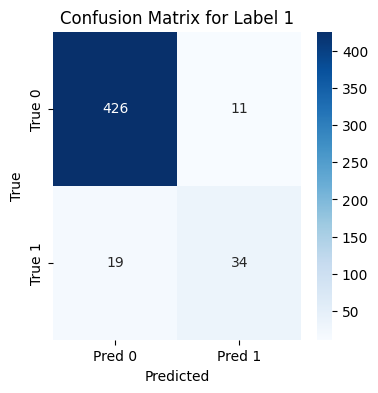

In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

label_index = 1

y_true = eval_labels[:, label_index]
y_pred_prob = calibrated_eval_probs[:, label_index]
threshold = ranking_metrics["thresholds"][label_index]

# Convert probabilities to 0/1 predictions
y_pred = (y_pred_prob >= threshold).astype(int)
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

plt.figure(figsize=(4, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred 0", "Pred 1"],
    yticklabels=["True 0", "True 1"]
)

plt.title(f"Confusion Matrix for Label {label_index}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [44]:
print("Prevalence = ", labels_df.iloc[:,label_index].mean())

Prevalence =  0.12326759061833689


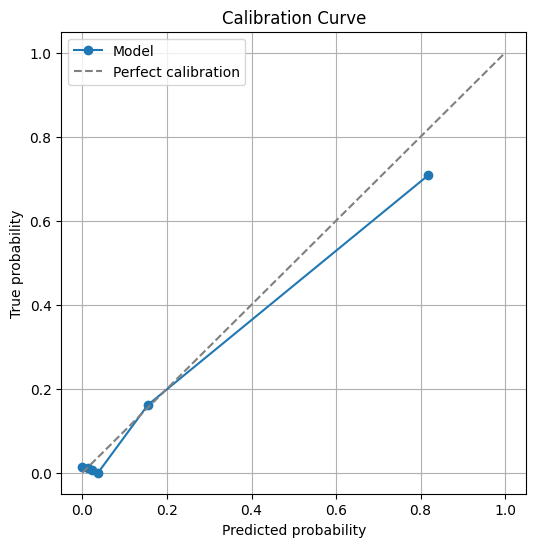

In [47]:
from sklearn.calibration import calibration_curve

y_true = eval_labels[:,label_index]
y_pred = calibrated_eval_probs[:,label_index]

prob_true, prob_pred = calibration_curve(y_true, y_pred, n_bins=10, strategy="quantile")
plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')

plt.xlabel("Predicted probability")
plt.ylabel("True probability")
plt.title("Calibration Curve")
plt.legend()
plt.grid(True)
plt.show()